# Vendor/Device Image Counts

This notebook builds barplots of image counts by vendor and by device using DICOM-derived CSVs.

It also uses the curated equipment registry (`mammography_equipment_reorganized.csv`) to provide context from papers/metadata curation (canonical vendor/model mentions).

In [2]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
if not (project_root / 'image_counts_by_vendor.csv').exists():
    project_root = project_root.parent

base = project_root
vendor_csv = base / 'image_counts_by_vendor.csv'
device_csv = base / 'image_counts_by_device.csv'
catalog_csv = base / 'mammography_equipment_reorganized.csv'

vendor_df = pd.read_csv(vendor_csv)
device_df = pd.read_csv(device_csv)
catalog_df = pd.read_csv(catalog_csv)

vendor_df.head(), device_df.head()

(               vendor  image_count
 0             UNKNOWN        60345
 1  GE MEDICAL SYSTEMS        24546
 2       HOLOGIC, Inc.         6716
 3             SIEMENS           21,
                vendor                                     device  image_count
 0             UNKNOWN                                    UNKNOWN        60345
 1  GE MEDICAL SYSTEMS  Senographe Essential VERSION ADS_53.10.10        24442
 2       HOLOGIC, Inc.                         Selenia Dimensions         6716
 3  GE MEDICAL SYSTEMS     Senographe Essential VERSION ADS_53.40           96
 4             SIEMENS                       Mammomat Novation DR           21)

In [3]:
def normalize_text(value: str) -> str:
    if pd.isna(value):
        return 'UNKNOWN'
    s = str(value).strip()
    if not s:
        return 'UNKNOWN'
    s = s.upper()
    s = re.sub(r'[^A-Z0-9]+', ' ', s).strip()
    return s or 'UNKNOWN'

# Build canonical vocab from curated catalog (papers + manual curation).
catalog_vendors = set(normalize_text(v) for v in catalog_df['vendor'].fillna('UNKNOWN'))
catalog_devices = set(normalize_text(m) for m in catalog_df['model'].fillna('UNKNOWN'))

vendor_df['vendor_norm'] = vendor_df['vendor'].map(normalize_text)
device_df['vendor_norm'] = device_df['vendor'].map(normalize_text)
device_df['device_norm'] = device_df['device'].map(normalize_text)

# Mark whether a vendor/device string has a direct match in curated registry context.
vendor_df['in_curated_registry'] = vendor_df['vendor_norm'].isin(catalog_vendors)
device_df['in_curated_registry'] = device_df['device_norm'].isin(catalog_devices)

vendor_df

,vendor,image_count,vendor_norm,in_curated_registry
0,UNKNOWN,60345,UNKNOWN,True
1,GE MEDICAL SYSTEMS,24546,GE MEDICAL SYSTEMS,False
2,"HOLOGIC, Inc.",6716,HOLOGIC INC,False
3,SIEMENS,21,SIEMENS,True


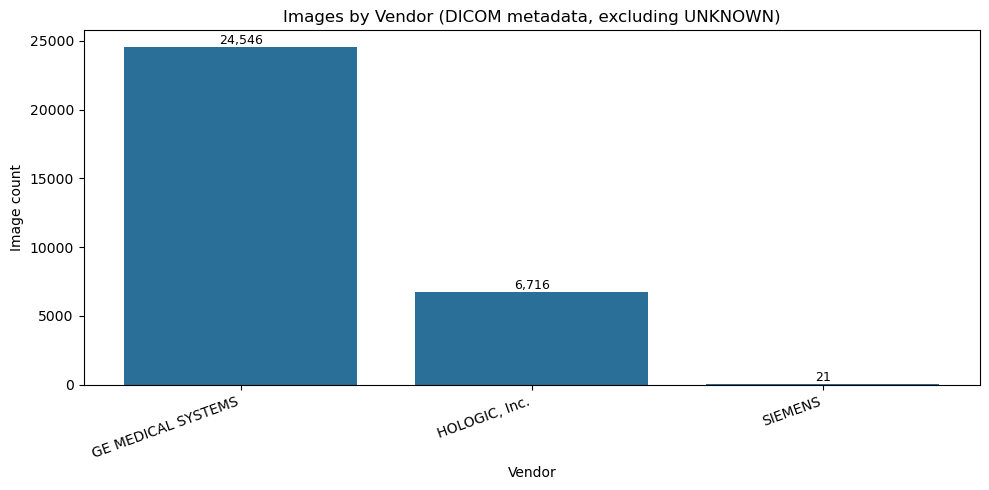

UNKNOWN images (not shown in bars): 60,345
Figure saved: /home/eloygarcia/Escritorio/WorkInProgress/Preprocessing/notebooks/images_by_vendor_barplot.png


In [4]:
# Keep UNKNOWN in a separate line to avoid dominating the plot.
vendor_known = vendor_df[vendor_df['vendor_norm'] != 'UNKNOWN'].copy()
vendor_unknown = int(vendor_df.loc[vendor_df['vendor_norm'] == 'UNKNOWN', 'image_count'].sum())

vendor_known = vendor_known.sort_values('image_count', ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(vendor_known['vendor'], vendor_known['image_count'], color='#2A6F97')
plt.title('Images by Vendor (DICOM metadata, excluding UNKNOWN)')
plt.xlabel('Vendor')
plt.ylabel('Image count')
plt.xticks(rotation=20, ha='right')

for b in bars:
    y = int(b.get_height())
    plt.text(b.get_x() + b.get_width() / 2, y, f'{y:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
vendor_fig = base / 'notebooks' / 'images_by_vendor_barplot.png'
plt.savefig(vendor_fig, dpi=180)
plt.show()

print(f'UNKNOWN images (not shown in bars): {vendor_unknown:,}')
print(f'Figure saved: {vendor_fig}')

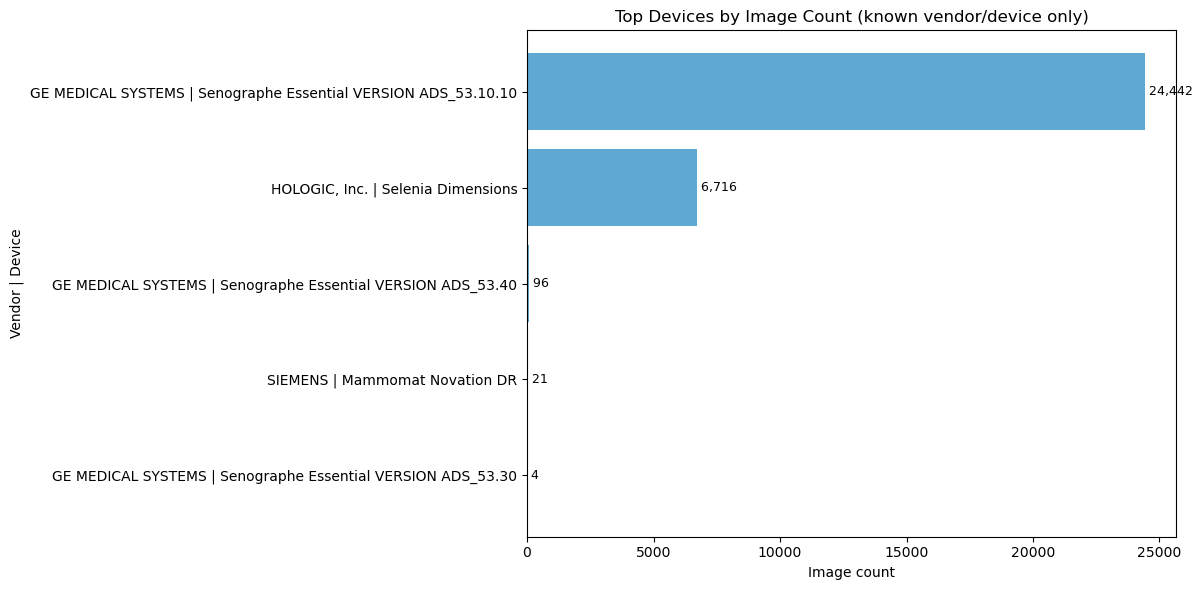

Figure saved: /home/eloygarcia/Escritorio/WorkInProgress/Preprocessing/notebooks/images_by_device_barplot.png


In [5]:
device_known = device_df[(device_df['vendor_norm'] != 'UNKNOWN') & (device_df['device_norm'] != 'UNKNOWN')].copy()
device_top = device_known.sort_values('image_count', ascending=False).head(12)
device_top['label'] = device_top['vendor'] + ' | ' + device_top['device']

plt.figure(figsize=(12, 6))
bars = plt.barh(device_top['label'][::-1], device_top['image_count'][::-1], color='#5FA8D3')
plt.title('Top Devices by Image Count (known vendor/device only)')
plt.xlabel('Image count')
plt.ylabel('Vendor | Device')

for b in bars:
    x = int(b.get_width())
    plt.text(x, b.get_y() + b.get_height() / 2, f' {x:,}', va='center', fontsize=9)

plt.tight_layout()
device_fig = base / 'notebooks' / 'images_by_device_barplot.png'
plt.savefig(device_fig, dpi=180)
plt.show()

print(f'Figure saved: {device_fig}')

In [6]:
summary = pd.DataFrame({
    'metric': [
        'Total images (all)',
        'Images with UNKNOWN vendor',
        'Known vendors in DICOM counts',
        'Vendors mentioned in curated registry',
        'Devices mentioned in curated registry'
    ],
    'value': [
        int(vendor_df['image_count'].sum()),
        vendor_unknown,
        int(vendor_known['vendor'].nunique()),
        int((catalog_df['vendor'].fillna('').astype(str).str.strip() != '').sum()),
        int((catalog_df['model'].fillna('').astype(str).str.strip() != '').sum())
    ]
})

summary

,metric,value
0,Total images (all),91628
1,Images with UNKNOWN vendor,60345
2,Known vendors in DICOM counts,3
3,Vendors mentioned in curated registry,55
4,Devices mentioned in curated registry,41


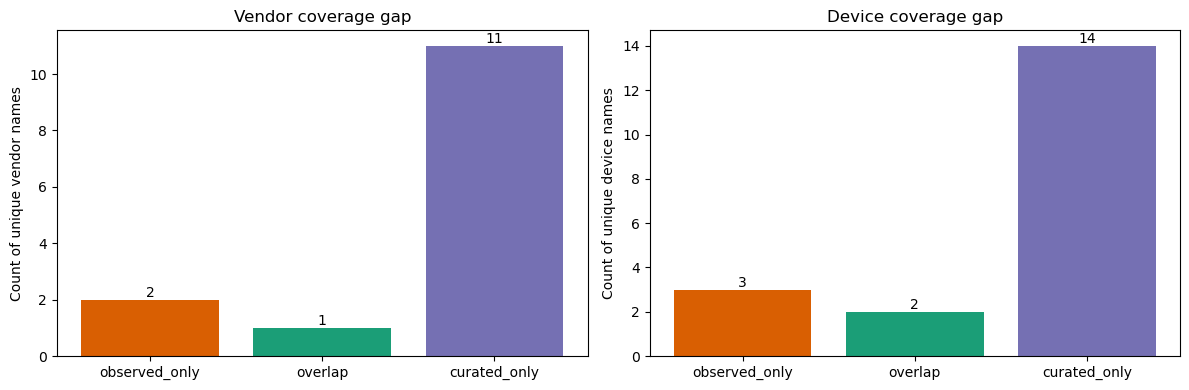

Figure saved: /home/eloygarcia/Escritorio/WorkInProgress/Preprocessing/notebooks/dicom_vs_curated_gap_analysis.png

Coverage summary:


,group,observed,curated,overlap
0,Vendors,3,12,1
1,Devices,5,16,2



Sample curated-only vendors (first 15):
['FISCHER', 'FUJIFILM', 'GE', 'HOLOGIC', 'IMS', 'KODAK', 'KONICA MINOLTA', 'MULTIPLE VENDORS', 'PHILIPS', 'PLANMED', 'SECTRA IMTEC']

Sample curated-only devices (first 15):
['AMULET INNOVALITY', 'FCR PROFECT CS', 'GIOTTO', 'GIOTTO 3DL', 'GIOTTO IMAGE SDL W', 'LORAD SELENIA', 'MAMMOMAT', 'MAMMOMAT INSPIRATION', 'MAMMOMAT REVELATION', 'MAMMONOVATION', 'SENOGRAPH ESSENTIAL', 'SENOGRAPHE 800T HIGH', 'SENOGRAPHE DS', 'SENOGRAPHE DS ESSENTIAL']


In [7]:
# Normalize observed sets
observed_vendors = set(vendor_df.loc[vendor_df['vendor_norm'] != 'UNKNOWN', 'vendor_norm'])
observed_devices = set(device_df.loc[device_df['device_norm'] != 'UNKNOWN', 'device_norm'])

# Normalize curated sets and exclude UNKNOWN entries
curated_vendors = set(x for x in catalog_vendors if x != 'UNKNOWN')
curated_devices = set(x for x in catalog_devices if x != 'UNKNOWN')

vendor_overlap = observed_vendors & curated_vendors
vendor_observed_only = observed_vendors - curated_vendors
vendor_curated_only = curated_vendors - observed_vendors

device_overlap = observed_devices & curated_devices
device_observed_only = observed_devices - curated_devices
device_curated_only = curated_devices - observed_devices

coverage = pd.DataFrame([
    {'group': 'Vendors', 'observed': len(observed_vendors), 'curated': len(curated_vendors), 'overlap': len(vendor_overlap)},
    {'group': 'Devices', 'observed': len(observed_devices), 'curated': len(curated_devices), 'overlap': len(device_overlap)},
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vendor_vals = [len(vendor_observed_only), len(vendor_overlap), len(vendor_curated_only)]
axes[0].bar(['observed_only', 'overlap', 'curated_only'], vendor_vals, color=['#d95f02', '#1b9e77', '#7570b3'])
axes[0].set_title('Vendor coverage gap')
axes[0].set_ylabel('Count of unique vendor names')
for i, v in enumerate(vendor_vals):
    axes[0].text(i, v, str(v), ha='center', va='bottom')

device_vals = [len(device_observed_only), len(device_overlap), len(device_curated_only)]
axes[1].bar(['observed_only', 'overlap', 'curated_only'], device_vals, color=['#d95f02', '#1b9e77', '#7570b3'])
axes[1].set_title('Device coverage gap')
axes[1].set_ylabel('Count of unique device names')
for i, v in enumerate(device_vals):
    axes[1].text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
gap_fig = base / 'notebooks' / 'dicom_vs_curated_gap_analysis.png'
plt.savefig(gap_fig, dpi=180)
plt.show()

print('Figure saved:', gap_fig)
print('\nCoverage summary:')
display(coverage)

print('\nSample curated-only vendors (first 15):')
print(sorted(list(vendor_curated_only))[:15])

print('\nSample curated-only devices (first 15):')
print(sorted(list(device_curated_only))[:15])

## Gap analysis: DICOM observed vs curated registry

This section compares what appears in real DICOM headers (current local datasets) against vendor/device names mentioned in the curated registry built from papers and metadata consolidation.

Interpretation:
- observed_only: appears in DICOM counts but not in curated registry names
- curated_only: appears in curated registry but not in current observed DICOM headers
- overlap: appears in both

## Corrected view for anonymized datasets (CMMD and INbreast)

DICOM headers for some datasets are anonymized (`UNKNOWN` vendor/device). Based on curated evidence in the equipment registry, this section applies an explicit dataset-level correction:

- CMMD -> SIEMENS | Mammomat Inspiration
- INbreast -> SIEMENS | MammoNovation

This produces an evidence-informed view while keeping raw DICOM counts unchanged in previous sections.

SIEMENS raw count: 21
SIEMENS corrected count: 5,633
Increase from CMMD + INbreast reassignment: 5,612


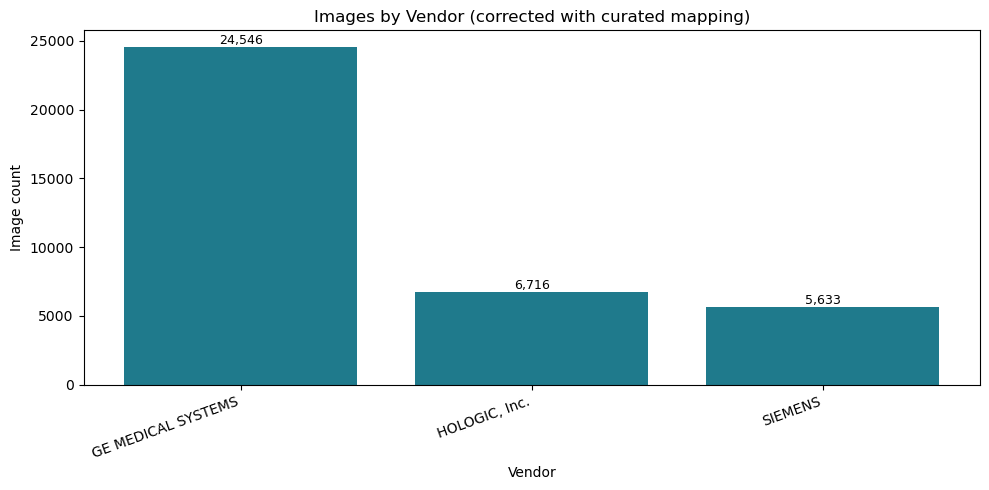

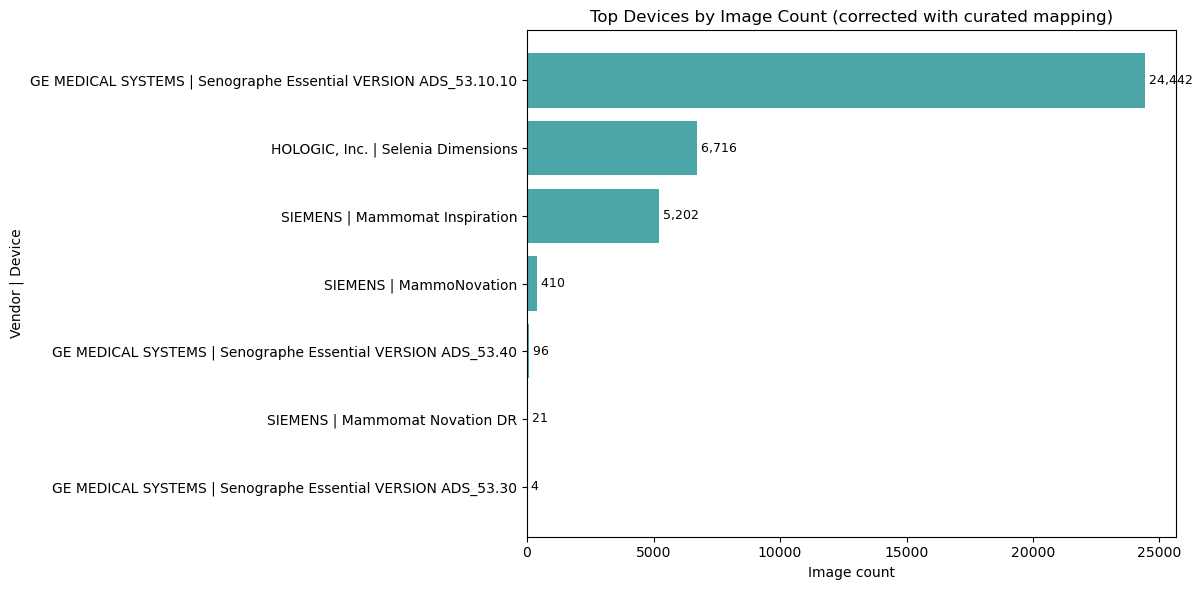

Figure saved: /home/eloygarcia/Escritorio/WorkInProgress/Preprocessing/notebooks/images_by_vendor_barplot_corrected.png
Figure saved: /home/eloygarcia/Escritorio/WorkInProgress/Preprocessing/notebooks/images_by_device_barplot_corrected.png


,metric,value
0,SIEMENS images (raw DICOM),21
1,SIEMENS images (corrected),5633
2,Delta SIEMENS,5612


In [8]:
dataset_vendor_df = pd.read_csv(base / 'image_counts_by_dataset_vendor.csv')
dataset_device_df = pd.read_csv(base / 'image_counts_by_dataset_device.csv')

inferred_mapping = {
    'CMMD': {'vendor': 'SIEMENS', 'device': 'Mammomat Inspiration'},
    'INbreast': {'vendor': 'SIEMENS', 'device': 'MammoNovation'},
}

vendor_adj = dataset_vendor_df.copy()
device_adj = dataset_device_df.copy()

for ds, mp in inferred_mapping.items():
    m_v = (vendor_adj['dataset'] == ds) & (vendor_adj['vendor'] == 'UNKNOWN')
    if m_v.any():
        moved = int(vendor_adj.loc[m_v, 'image_count'].sum())
        vendor_adj = vendor_adj.loc[~m_v].copy()
        vendor_adj = pd.concat(
            [vendor_adj, pd.DataFrame([{'dataset': ds, 'vendor': mp['vendor'], 'image_count': moved}])],
            ignore_index=True,
        )

    m_d = (device_adj['dataset'] == ds) & (device_adj['vendor'] == 'UNKNOWN') & (device_adj['device'] == 'UNKNOWN')
    if m_d.any():
        moved = int(device_adj.loc[m_d, 'image_count'].sum())
        device_adj = device_adj.loc[~m_d].copy()
        device_adj = pd.concat(
            [device_adj, pd.DataFrame([{'dataset': ds, 'vendor': mp['vendor'], 'device': mp['device'], 'image_count': moved}])],
            ignore_index=True,
        )

vendor_counts_adj = vendor_adj.groupby('vendor', as_index=False)['image_count'].sum().sort_values('image_count', ascending=False)
device_counts_adj = device_adj.groupby(['vendor', 'device'], as_index=False)['image_count'].sum().sort_values('image_count', ascending=False)

siemens_raw = int(vendor_df.loc[vendor_df['vendor'] == 'SIEMENS', 'image_count'].sum())
siemens_adj = int(vendor_counts_adj.loc[vendor_counts_adj['vendor'] == 'SIEMENS', 'image_count'].sum())

print(f'SIEMENS raw count: {siemens_raw:,}')
print(f'SIEMENS corrected count: {siemens_adj:,}')
print(f'Increase from CMMD + INbreast reassignment: {siemens_adj - siemens_raw:,}')

vendor_plot = vendor_counts_adj[vendor_counts_adj['vendor'] != 'UNKNOWN'].copy()

plt.figure(figsize=(10, 5))
bars = plt.bar(vendor_plot['vendor'], vendor_plot['image_count'], color='#1f7a8c')
plt.title('Images by Vendor (corrected with curated mapping)')
plt.xlabel('Vendor')
plt.ylabel('Image count')
plt.xticks(rotation=20, ha='right')
for b in bars:
    y = int(b.get_height())
    plt.text(b.get_x() + b.get_width() / 2, y, f'{y:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
corrected_vendor_fig = base / 'notebooks' / 'images_by_vendor_barplot_corrected.png'
plt.savefig(corrected_vendor_fig, dpi=180)
plt.show()

known_device_adj = device_counts_adj[(device_counts_adj['vendor'] != 'UNKNOWN') & (device_counts_adj['device'] != 'UNKNOWN')].copy()
top_device_adj = known_device_adj.head(12).copy()
top_device_adj['label'] = top_device_adj['vendor'] + ' | ' + top_device_adj['device']

plt.figure(figsize=(12, 6))
bars = plt.barh(top_device_adj['label'][::-1], top_device_adj['image_count'][::-1], color='#4ca6a8')
plt.title('Top Devices by Image Count (corrected with curated mapping)')
plt.xlabel('Image count')
plt.ylabel('Vendor | Device')
for b in bars:
    x = int(b.get_width())
    plt.text(x, b.get_y() + b.get_height() / 2, f' {x:,}', va='center', fontsize=9)
plt.tight_layout()
corrected_device_fig = base / 'notebooks' / 'images_by_device_barplot_corrected.png'
plt.savefig(corrected_device_fig, dpi=180)
plt.show()

print('Figure saved:', corrected_vendor_fig)
print('Figure saved:', corrected_device_fig)

comparison = pd.DataFrame([
    {'metric': 'SIEMENS images (raw DICOM)', 'value': siemens_raw},
    {'metric': 'SIEMENS images (corrected)', 'value': siemens_adj},
    {'metric': 'Delta SIEMENS', 'value': siemens_adj - siemens_raw},
])

comparison

## Cases by dataset, vendor and device

This section expands the study to a dataset-level view and reports case counts for each `(dataset, vendor, device)` combination.

Outputs:
- Raw DICOM metadata counts (as-is)
- Corrected counts for anonymized datasets using curated mapping
- Pivot charts by dataset and vendor

Saved: /home/eloygarcia/Escritorio/WorkInProgress/Preprocessing/dataset_vendor_device_case_counts_raw.csv
Saved: /home/eloygarcia/Escritorio/WorkInProgress/Preprocessing/dataset_vendor_device_case_counts_corrected.csv

Raw cases (dataset-vendor-device):


,dataset,vendor,device,case_count
0,CMMD,UNKNOWN,UNKNOWN,5202
1,INbreast,UNKNOWN,UNKNOWN,410
2,Mammo-MX,"HOLOGIC, Inc.",Selenia Dimensions,6716
3,Mammo-MX,UNKNOWN,UNKNOWN,1
4,NL-breast,GE MEDICAL SYSTEMS,Senographe Essential VERSION ADS_53.10.10,24442
5,NL-breast,GE MEDICAL SYSTEMS,Senographe Essential VERSION ADS_53.40,96
6,NL-breast,UNKNOWN,UNKNOWN,22
7,NL-breast,SIEMENS,Mammomat Novation DR,21
8,NL-breast,GE MEDICAL SYSTEMS,Senographe Essential VERSION ADS_53.30,4
9,NL-breast,GE MEDICAL SYSTEMS,UNKNOWN,4



Corrected cases (dataset-vendor-device):


,dataset,vendor,device,case_count
0,CMMD,SIEMENS,Mammomat Inspiration,5202
1,INbreast,SIEMENS,MammoNovation,410
2,Mammo-MX,"HOLOGIC, Inc.",Selenia Dimensions,6716
3,Mammo-MX,UNKNOWN,UNKNOWN,1
4,NL-breast,GE MEDICAL SYSTEMS,Senographe Essential VERSION ADS_53.10.10,24442
5,NL-breast,GE MEDICAL SYSTEMS,Senographe Essential VERSION ADS_53.40,96
6,NL-breast,UNKNOWN,UNKNOWN,22
7,NL-breast,SIEMENS,Mammomat Novation DR,21
8,NL-breast,GE MEDICAL SYSTEMS,Senographe Essential VERSION ADS_53.30,4
9,NL-breast,GE MEDICAL SYSTEMS,UNKNOWN,4


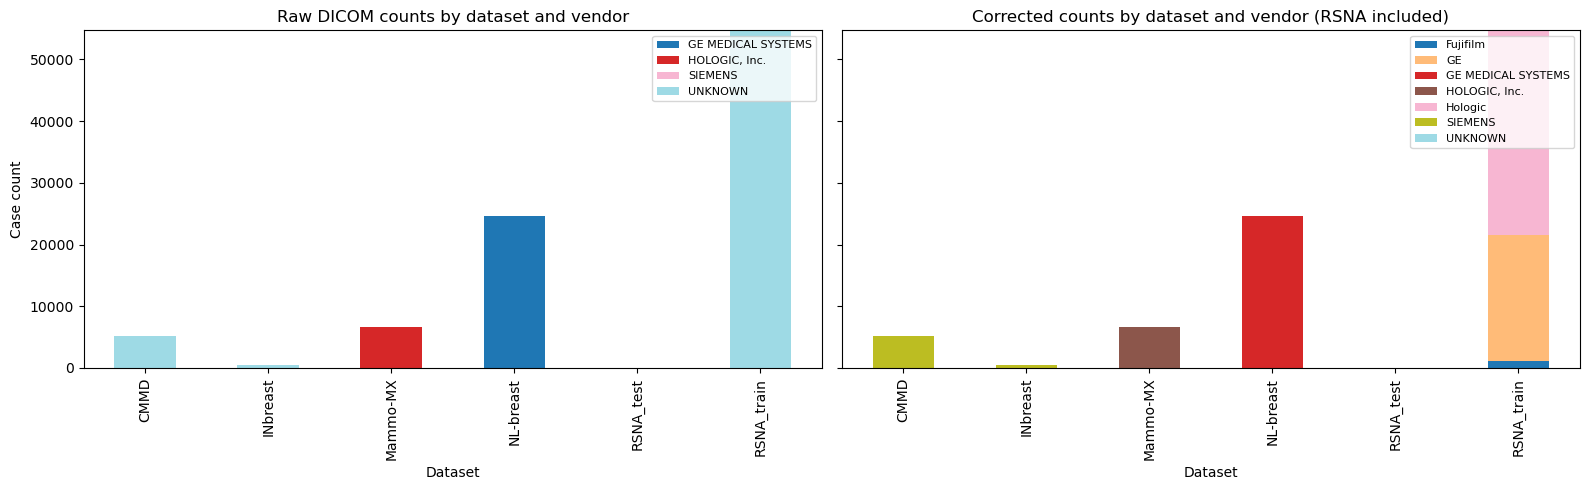

Figure saved: /home/eloygarcia/Escritorio/WorkInProgress/Preprocessing/notebooks/dataset_vendor_stacked_raw_vs_corrected.png


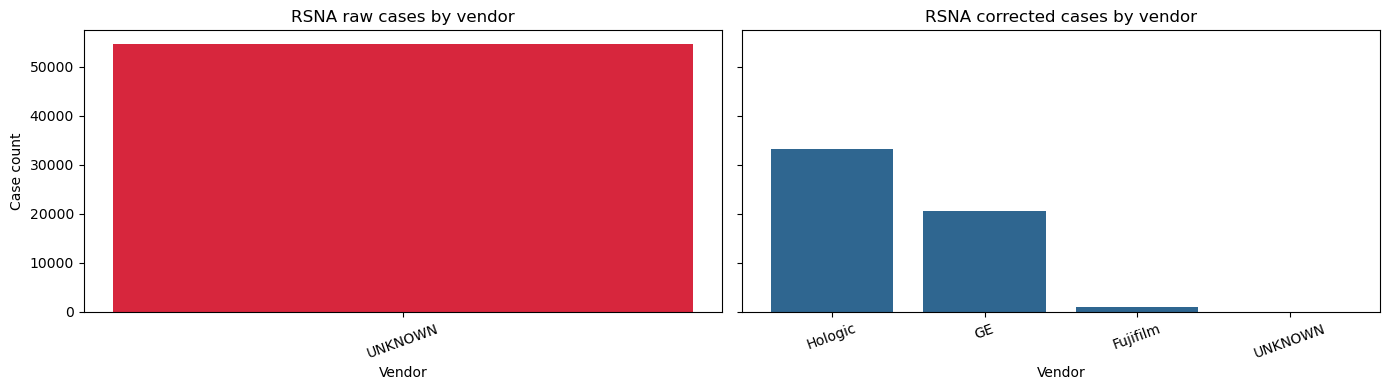

Figure saved: /home/eloygarcia/Escritorio/WorkInProgress/Preprocessing/notebooks/rsna_raw_vs_corrected_cases.png


,dataset,vendor,device,case_count
0,CMMD,SIEMENS,Mammomat Inspiration,5202
1,INbreast,SIEMENS,MammoNovation,410
2,Mammo-MX,"HOLOGIC, Inc.",Selenia Dimensions,6716
3,Mammo-MX,UNKNOWN,UNKNOWN,1
4,NL-breast,GE MEDICAL SYSTEMS,Senographe Essential VERSION ADS_53.10.10,24442
5,NL-breast,GE MEDICAL SYSTEMS,Senographe Essential VERSION ADS_53.40,96
6,NL-breast,GE MEDICAL SYSTEMS,Senographe Essential VERSION ADS_53.30,4
7,NL-breast,GE MEDICAL SYSTEMS,UNKNOWN,4
8,NL-breast,SIEMENS,Mammomat Novation DR,21
9,NL-breast,UNKNOWN,UNKNOWN,22


In [12]:
dataset_vendor_df = pd.read_csv(base / 'image_counts_by_dataset_vendor.csv')
dataset_device_df = pd.read_csv(base / 'image_counts_by_dataset_device.csv')

# Raw cases table: one row per dataset/vendor/device
cases_raw = (
    dataset_device_df
    .rename(columns={'image_count': 'case_count'})
    .sort_values(['dataset', 'case_count'], ascending=[True, False])
    .reset_index(drop=True)
)

# Start corrected table from raw
cases_corrected = cases_raw.copy()

# 1) Reuse explicit curated mapping for anonymized datasets
inferred_mapping = {
    'CMMD': {'vendor': 'SIEMENS', 'device': 'Mammomat Inspiration'},
    'INbreast': {'vendor': 'SIEMENS', 'device': 'MammoNovation'},
}

for ds, mp in inferred_mapping.items():
    mask = (
        (cases_corrected['dataset'] == ds)
        & (cases_corrected['vendor'] == 'UNKNOWN')
        & (cases_corrected['device'] == 'UNKNOWN')
    )
    if mask.any():
        moved = int(cases_corrected.loc[mask, 'case_count'].sum())
        cases_corrected = cases_corrected.loc[~mask].copy()
        cases_corrected = pd.concat(
            [
                cases_corrected,
                pd.DataFrame([
                    {'dataset': ds, 'vendor': mp['vendor'], 'device': mp['device'], 'case_count': moved}
                ])
            ],
            ignore_index=True,
        )

# 2) Add RSNA vendor/device split from curated registry stats
#    Expected from notes: Hologic 33,151 | GE 20,485 | Fujifilm 1,070 (total 54,706)
rsna_catalog = catalog_df[catalog_df['datasets'].fillna('').str.contains(r'\bRSNA\b', case=False, regex=True)].copy()
rsna_catalog['notes_clean'] = rsna_catalog['notes'].fillna('').astype(str)
rsna_catalog['rsna_images'] = (
    rsna_catalog['notes_clean']
    .str.extract(r'\(([\d,]+)\s*images\)', expand=False)
    .str.replace(',', '', regex=False)
)
rsna_catalog['rsna_images'] = pd.to_numeric(rsna_catalog['rsna_images'], errors='coerce')

rsna_curated = (
    rsna_catalog.dropna(subset=['rsna_images'])[['vendor', 'model', 'rsna_images']]
    .drop_duplicates()
    .sort_values('rsna_images', ascending=False)
    .reset_index(drop=True)
)

rsna_train_mask = (
    (cases_corrected['dataset'] == 'RSNA_train')
    & (cases_corrected['vendor'] == 'UNKNOWN')
    & (cases_corrected['device'] == 'UNKNOWN')
)

if rsna_train_mask.any() and not rsna_curated.empty:
    rsna_train_unknown = int(cases_corrected.loc[rsna_train_mask, 'case_count'].sum())
    rsna_curated_sum = int(rsna_curated['rsna_images'].sum())

    # Remove RSNA_train UNKNOWN row and replace with curated split
    cases_corrected = cases_corrected.loc[~rsna_train_mask].copy()

    rsna_rows = []
    for _, r in rsna_curated.iterrows():
        rsna_rows.append({
            'dataset': 'RSNA_train',
            'vendor': str(r['vendor']),
            'device': str(r['model']),
            'case_count': int(r['rsna_images']),
        })

    # Keep any residual as UNKNOWN if local count is larger than curated split
    residual = rsna_train_unknown - rsna_curated_sum
    if residual > 0:
        rsna_rows.append({
            'dataset': 'RSNA_train',
            'vendor': 'UNKNOWN',
            'device': 'UNKNOWN',
            'case_count': residual,
        })

    cases_corrected = pd.concat([cases_corrected, pd.DataFrame(rsna_rows)], ignore_index=True)

cases_corrected = cases_corrected.sort_values(['dataset', 'case_count'], ascending=[True, False]).reset_index(drop=True)

# Save explicit study outputs
raw_cases_csv = base / 'dataset_vendor_device_case_counts_raw.csv'
corrected_cases_csv = base / 'dataset_vendor_device_case_counts_corrected.csv'
cases_raw.to_csv(raw_cases_csv, index=False)
cases_corrected.to_csv(corrected_cases_csv, index=False)

print('Saved:', raw_cases_csv)
print('Saved:', corrected_cases_csv)

print('\nRaw cases (dataset-vendor-device):')
display(cases_raw)

print('\nCorrected cases (dataset-vendor-device):')
display(cases_corrected)

# Dataset x vendor stacked bars (raw vs corrected), now including RSNA curated split in corrected
raw_pivot = (
    cases_raw.groupby(['dataset', 'vendor'])['case_count']
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

corrected_pivot = (
    cases_corrected.groupby(['dataset', 'vendor'])['case_count']
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
raw_pivot.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab20')
axes[0].set_title('Raw DICOM counts by dataset and vendor')
axes[0].set_xlabel('Dataset')
axes[0].set_ylabel('Case count')
axes[0].legend(loc='upper right', fontsize=8)

corrected_pivot.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
axes[1].set_title('Corrected counts by dataset and vendor (RSNA included)')
axes[1].set_xlabel('Dataset')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
dataset_vendor_fig = base / 'notebooks' / 'dataset_vendor_stacked_raw_vs_corrected.png'
plt.savefig(dataset_vendor_fig, dpi=180)
plt.show()
print('Figure saved:', dataset_vendor_fig)

# Dedicated RSNA-only comparison figure (raw vs corrected)
rsna_raw_vendor = (
    cases_raw[cases_raw['dataset'].isin(['RSNA_train', 'RSNA_test'])]
    .groupby('vendor', as_index=False)['case_count']
    .sum()
    .sort_values('case_count', ascending=False)
)

rsna_corrected_vendor = (
    cases_corrected[cases_corrected['dataset'].isin(['RSNA_train', 'RSNA_test'])]
    .groupby('vendor', as_index=False)['case_count']
    .sum()
    .sort_values('case_count', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
axes[0].bar(rsna_raw_vendor['vendor'], rsna_raw_vendor['case_count'], color='#d7263d')
axes[0].set_title('RSNA raw cases by vendor')
axes[0].set_xlabel('Vendor')
axes[0].set_ylabel('Case count')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(rsna_corrected_vendor['vendor'], rsna_corrected_vendor['case_count'], color='#2f6690')
axes[1].set_title('RSNA corrected cases by vendor')
axes[1].set_xlabel('Vendor')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
rsna_raw_corrected_fig = base / 'notebooks' / 'rsna_raw_vs_corrected_cases.png'
plt.savefig(rsna_raw_corrected_fig, dpi=180)
plt.show()
print('Figure saved:', rsna_raw_corrected_fig)

# Compact report focused on requested metric
report = cases_corrected.sort_values(['dataset', 'vendor', 'case_count'], ascending=[True, True, False]).reset_index(drop=True)
report

## RSNA curated statistics from equipment registry

This section uses RSNA-specific statistics from the curated registry (`mammography_equipment_reorganized.csv`) and summarizes expected distribution by vendor/model.

Note: these are curated paper/metadata statistics, complementary to raw DICOM header counts (which can be anonymized).

RSNA curated total images (from registry stats): 54,706
RSNA observed total images in local count (train+test): 54,710
Difference (observed - curated): 4
Saved: /home/eloygarcia/Escritorio/WorkInProgress/Preprocessing/rsna_curated_vendor_device_stats.csv


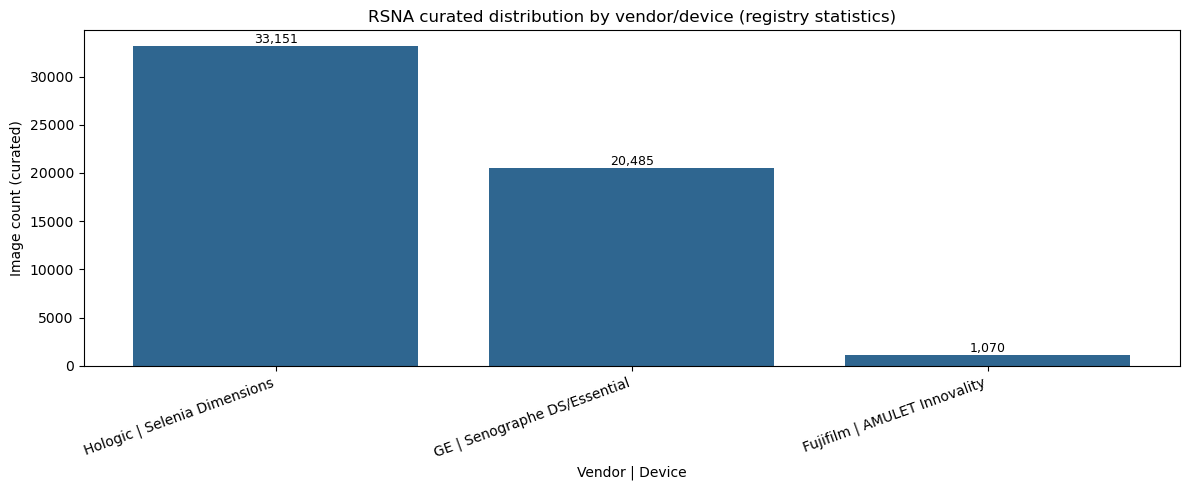

Figure saved: /home/eloygarcia/Escritorio/WorkInProgress/Preprocessing/notebooks/rsna_curated_vendor_device_barplot.png


,vendor,model,rsna_percent,rsna_images,share_from_images_%
0,Hologic,Selenia Dimensions,60.0,33151,60.60
1,GE,Senographe DS/Essential,37.0,20485,37.45
2,Fujifilm,AMULET Innovality,2.0,1070,1.96


In [10]:
import numpy as np

# Filter RSNA rows from curated registry
df_rsna = catalog_df[catalog_df['datasets'].fillna('').str.contains(r'\bRSNA\b', case=False, regex=True)].copy()

# Extract stats from notes like: "60% of dataset (33,151 images)"
df_rsna['notes_clean'] = df_rsna['notes'].fillna('').astype(str)
df_rsna['rsna_percent'] = (
    df_rsna['notes_clean']
    .str.extract(r'(\d+(?:\.\d+)?)%\s*of\s*dataset', expand=False)
    .astype(float)
)
df_rsna['rsna_images'] = (
    df_rsna['notes_clean']
    .str.extract(r'\(([\d,]+)\s*images\)', expand=False)
    .str.replace(',', '', regex=False)
)
df_rsna['rsna_images'] = pd.to_numeric(df_rsna['rsna_images'], errors='coerce')

# Keep only rows with explicit RSNA stats and deduplicate repeated matrix-size rows
rsna_stats = df_rsna.dropna(subset=['rsna_images']).copy()
rsna_stats = (
    rsna_stats[['vendor', 'model', 'rsna_percent', 'rsna_images']]
    .drop_duplicates()
    .sort_values('rsna_images', ascending=False)
    .reset_index(drop=True)
)

# Curated totals and shares
curated_total = int(rsna_stats['rsna_images'].sum()) if not rsna_stats.empty else 0
if curated_total > 0:
    rsna_stats['share_from_images_%'] = (100 * rsna_stats['rsna_images'] / curated_total).round(2)
else:
    rsna_stats['share_from_images_%'] = np.nan

# Compare against observed RSNA counts from current local scan
rsna_observed_total = int(
    cases_raw.loc[cases_raw['dataset'].isin(['RSNA_train', 'RSNA_test']), 'case_count'].sum()
)

print(f'RSNA curated total images (from registry stats): {curated_total:,}')
print(f'RSNA observed total images in local count (train+test): {rsna_observed_total:,}')
print(f'Difference (observed - curated): {rsna_observed_total - curated_total:,}')

# Save RSNA stats table
rsna_stats_csv = base / 'rsna_curated_vendor_device_stats.csv'
rsna_stats.to_csv(rsna_stats_csv, index=False)
print('Saved:', rsna_stats_csv)

# Plot curated RSNA distribution by vendor-model
plot_df = rsna_stats.copy()
plot_df['label'] = plot_df['vendor'].fillna('UNKNOWN') + ' | ' + plot_df['model'].fillna('UNKNOWN')

plt.figure(figsize=(12, 5))
bars = plt.bar(plot_df['label'], plot_df['rsna_images'], color='#2f6690')
plt.title('RSNA curated distribution by vendor/device (registry statistics)')
plt.xlabel('Vendor | Device')
plt.ylabel('Image count (curated)')
plt.xticks(rotation=20, ha='right')
for b in bars:
    y = int(b.get_height())
    plt.text(b.get_x() + b.get_width() / 2, y, f'{y:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
rsna_curated_fig = base / 'notebooks' / 'rsna_curated_vendor_device_barplot.png'
plt.savefig(rsna_curated_fig, dpi=180)
plt.show()
print('Figure saved:', rsna_curated_fig)

# Final RSNA table for display
rsna_stats

## RSNA curated vs observed (metadata gap)

Side-by-side comparison between:
- Curated RSNA vendor/device distribution (from equipment registry stats)
- Observed RSNA DICOM metadata distribution in local files (mostly anonymized as UNKNOWN)

This makes the metadata-anonymization gap explicit.

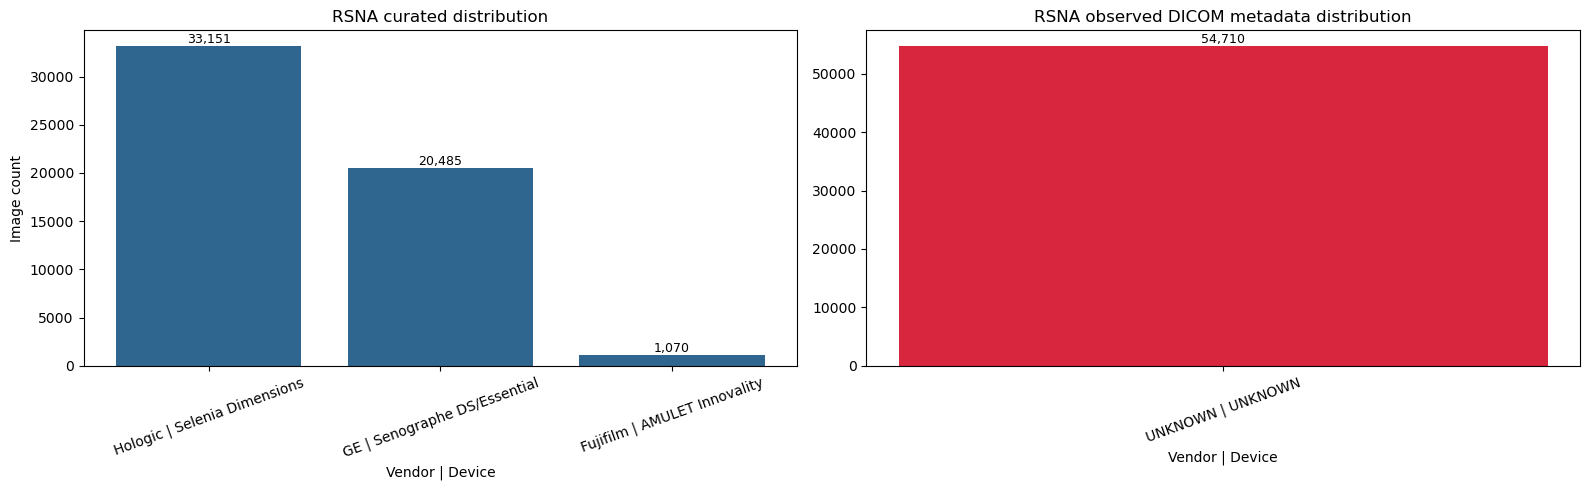

Figure saved: /home/eloygarcia/Escritorio/WorkInProgress/Preprocessing/notebooks/rsna_curated_vs_observed_gap.png


,metric,value
0,RSNA curated total,54706
1,RSNA observed total (all labels),54710
2,Observed UNKNOWN | UNKNOWN,54710


In [11]:
# Curated RSNA distribution
curated_plot = rsna_stats.copy()
curated_plot['label'] = curated_plot['vendor'].fillna('UNKNOWN') + ' | ' + curated_plot['model'].fillna('UNKNOWN')
curated_plot = curated_plot[['label', 'rsna_images']].rename(columns={'rsna_images': 'count'})
curated_plot['source'] = 'Curated registry'

# Observed RSNA distribution from raw DICOM metadata
rsna_obs = (
    cases_raw[cases_raw['dataset'].isin(['RSNA_train', 'RSNA_test'])]
    .copy()
)
rsna_obs['label'] = rsna_obs['vendor'].fillna('UNKNOWN') + ' | ' + rsna_obs['device'].fillna('UNKNOWN')
rsna_obs = (
    rsna_obs.groupby('label', as_index=False)['case_count']
    .sum()
    .rename(columns={'case_count': 'count'})
)
rsna_obs['source'] = 'Observed DICOM metadata'

# Keep top labels for readability
curated_plot = curated_plot.sort_values('count', ascending=False).head(6)
rsna_obs = rsna_obs.sort_values('count', ascending=False).head(6)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

# Left: curated
axes[0].bar(curated_plot['label'], curated_plot['count'], color='#2f6690')
axes[0].set_title('RSNA curated distribution')
axes[0].set_xlabel('Vendor | Device')
axes[0].set_ylabel('Image count')
axes[0].tick_params(axis='x', rotation=20)
for i, val in enumerate(curated_plot['count']):
    axes[0].text(i, int(val), f'{int(val):,}', ha='center', va='bottom', fontsize=9)

# Right: observed
axes[1].bar(rsna_obs['label'], rsna_obs['count'], color='#d7263d')
axes[1].set_title('RSNA observed DICOM metadata distribution')
axes[1].set_xlabel('Vendor | Device')
axes[1].tick_params(axis='x', rotation=20)
for i, val in enumerate(rsna_obs['count']):
    axes[1].text(i, int(val), f'{int(val):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
rsna_gap_fig = base / 'notebooks' / 'rsna_curated_vs_observed_gap.png'
plt.savefig(rsna_gap_fig, dpi=180)
plt.show()

# Compact reconciliation table
reconciliation = pd.DataFrame([
    {'metric': 'RSNA curated total', 'value': int(curated_plot['count'].sum())},
    {'metric': 'RSNA observed total (all labels)', 'value': int(rsna_obs['count'].sum())},
    {'metric': 'Observed UNKNOWN | UNKNOWN', 'value': int(rsna_obs.loc[rsna_obs['label'] == 'UNKNOWN | UNKNOWN', 'count'].sum())},
])

print('Figure saved:', rsna_gap_fig)
display(reconciliation)

## Harmonized vendor labels (clean raw vs corrected figures)

This section harmonizes vendor aliases before plotting (e.g., `GE` and `GE MEDICAL SYSTEMS`, `Hologic` and `HOLOGIC, Inc.`) so comparisons are easier to read.

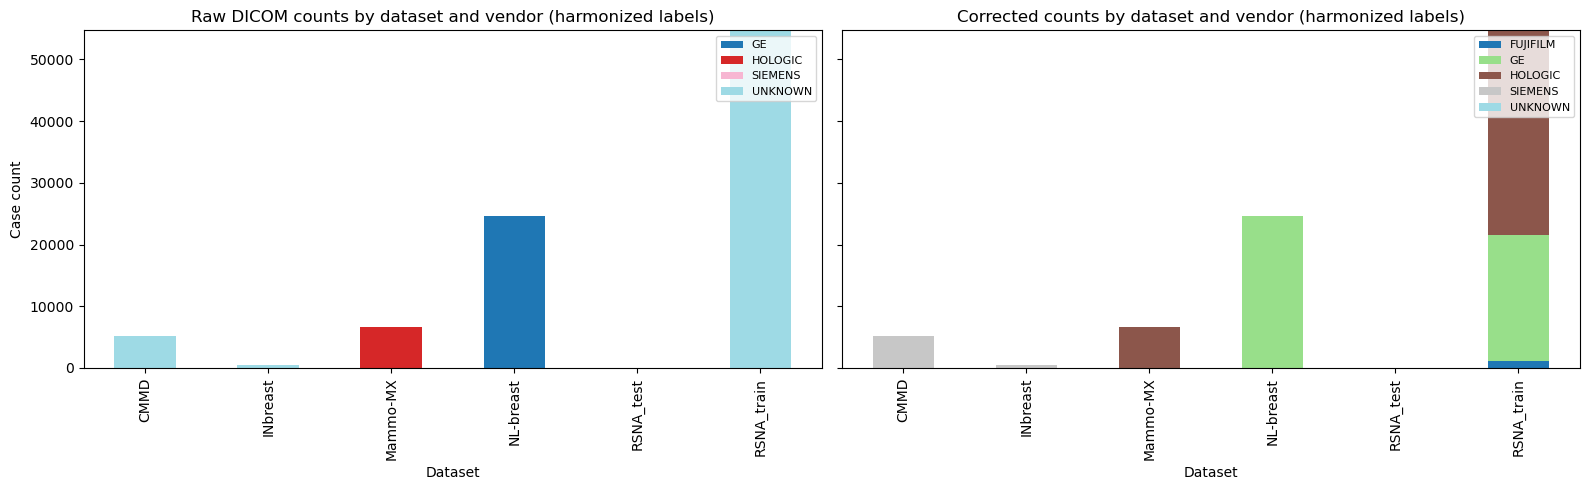

Figure saved: /home/eloygarcia/Escritorio/WorkInProgress/Preprocessing/notebooks/dataset_vendor_stacked_raw_vs_corrected_harmonized.png


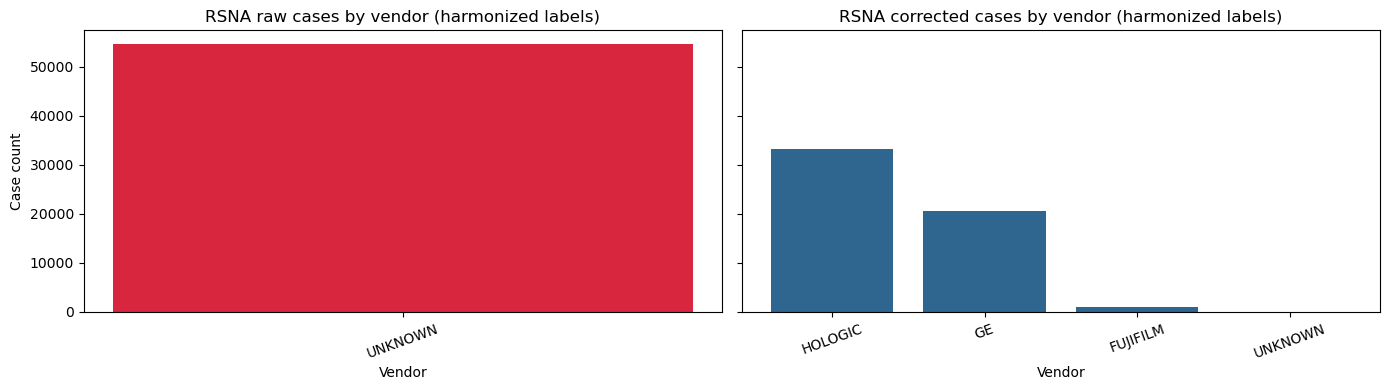

Figure saved: /home/eloygarcia/Escritorio/WorkInProgress/Preprocessing/notebooks/rsna_raw_vs_corrected_cases_harmonized.png


,vendor_plot,case_count
2,HOLOGIC,33151
1,GE,20485
0,FUJIFILM,1070
3,UNKNOWN,4


In [13]:
def canonical_vendor(v):
    s = str(v).strip().upper()
    alias = {
        'GE MEDICAL SYSTEMS': 'GE',
        'GE': 'GE',
        'HOLOGIC, INC.': 'HOLOGIC',
        'HOLOGIC': 'HOLOGIC',
        'SIEMENS': 'SIEMENS',
        'FUJIFILM': 'FUJIFILM',
        'UNKNOWN': 'UNKNOWN',
    }
    return alias.get(s, s)

raw_plot_df = cases_raw.copy()
corrected_plot_df = cases_corrected.copy()

raw_plot_df['vendor_plot'] = raw_plot_df['vendor'].map(canonical_vendor)
corrected_plot_df['vendor_plot'] = corrected_plot_df['vendor'].map(canonical_vendor)

raw_pivot_h = (
    raw_plot_df.groupby(['dataset', 'vendor_plot'])['case_count']
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

corrected_pivot_h = (
    corrected_plot_df.groupby(['dataset', 'vendor_plot'])['case_count']
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
raw_pivot_h.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab20')
axes[0].set_title('Raw DICOM counts by dataset and vendor (harmonized labels)')
axes[0].set_xlabel('Dataset')
axes[0].set_ylabel('Case count')
axes[0].legend(loc='upper right', fontsize=8)

corrected_pivot_h.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
axes[1].set_title('Corrected counts by dataset and vendor (harmonized labels)')
axes[1].set_xlabel('Dataset')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
harmonized_dataset_fig = base / 'notebooks' / 'dataset_vendor_stacked_raw_vs_corrected_harmonized.png'
plt.savefig(harmonized_dataset_fig, dpi=180)
plt.show()
print('Figure saved:', harmonized_dataset_fig)

rsna_raw_h = (
    raw_plot_df[raw_plot_df['dataset'].isin(['RSNA_train', 'RSNA_test'])]
    .groupby('vendor_plot', as_index=False)['case_count']
    .sum()
    .sort_values('case_count', ascending=False)
)

rsna_corr_h = (
    corrected_plot_df[corrected_plot_df['dataset'].isin(['RSNA_train', 'RSNA_test'])]
    .groupby('vendor_plot', as_index=False)['case_count']
    .sum()
    .sort_values('case_count', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
axes[0].bar(rsna_raw_h['vendor_plot'], rsna_raw_h['case_count'], color='#d7263d')
axes[0].set_title('RSNA raw cases by vendor (harmonized labels)')
axes[0].set_xlabel('Vendor')
axes[0].set_ylabel('Case count')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(rsna_corr_h['vendor_plot'], rsna_corr_h['case_count'], color='#2f6690')
axes[1].set_title('RSNA corrected cases by vendor (harmonized labels)')
axes[1].set_xlabel('Vendor')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
harmonized_rsna_fig = base / 'notebooks' / 'rsna_raw_vs_corrected_cases_harmonized.png'
plt.savefig(harmonized_rsna_fig, dpi=180)
plt.show()
print('Figure saved:', harmonized_rsna_fig)

rsna_corr_h